In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report,confusion_matrix,mean_squared_error, r2_score ,mean_absolute_error,root_mean_squared_error
  
from sklearn.model_selection import cross_val_score,GridSearchCV



In [325]:
df = pd.read_csv("car.csv")
print(df.head(15))
print(df.size)
print(df.isnull().sum())
print(df.reindex(df.columns.tolist(), axis=1))
print(df.dtypes)
print(df["Car_Name"])
print(df.shape)
print(df["Seller_Type"]
      )

         Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0            ritz  2014           3.35           5.59       27000    Petrol   
1             sx4  2013           4.75           9.54       43000    Diesel   
2            ciaz  2017           7.25           9.85        6900    Petrol   
3         wagon r  2011           2.85           4.15        5200    Petrol   
4           swift  2014           4.60           6.87       42450    Diesel   
5   vitara brezza  2018           9.25           9.83        2071    Diesel   
6            ciaz  2015           6.75           8.12       18796    Petrol   
7         s cross  2015           6.50           8.61       33429    Diesel   
8            ciaz  2016           8.75           8.89       20273    Diesel   
9            ciaz  2015           7.45           8.92       42367    Diesel   
10       alto 800  2017           2.85           3.60        2135    Petrol   
11           ciaz  2015           6.85          10.3

In [326]:
y=df["Selling_Price"]
print(y.describe())

count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64


EDA


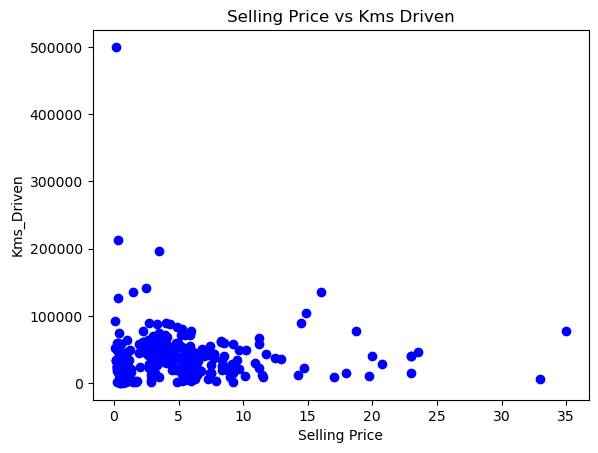

In [327]:
x=df["Selling_Price"]
y = df["Kms_Driven"]
plt.scatter(x, y, color='blue')
plt.xlabel('Selling Price')
plt.ylabel('Kms_Driven')
plt.title('Selling Price vs Kms Driven')
plt.show()

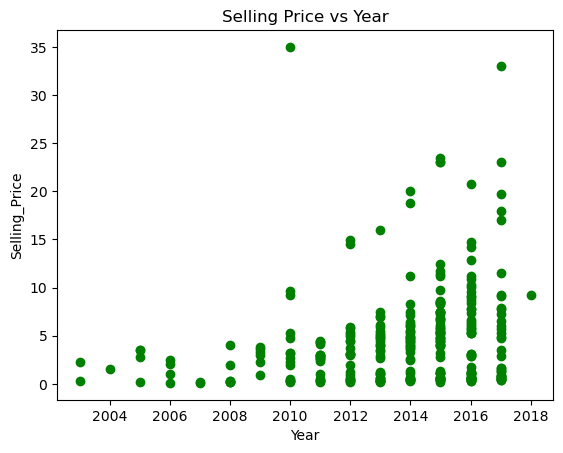

In [328]:
x=df["Year"]
y = df["Selling_Price"]
plt.scatter(x, y, color='green')
plt.xlabel('Year')
plt.ylabel('Selling_Price')
plt.title('Selling Price vs Year')
plt.show()

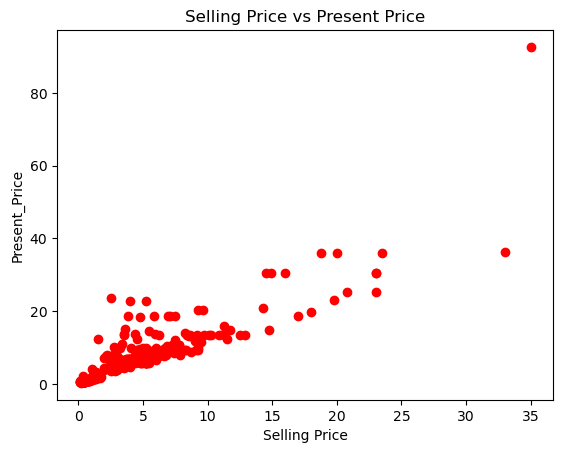

In [329]:
x=df["Selling_Price"]
y = df["Present_Price"]
plt.scatter(x, y, color='red')
plt.xlabel('Selling Price')
plt.ylabel('Present_Price')
plt.title('Selling Price vs Present Price')
plt.show()

C:\Users\bahug\AppData\Local\Temp\ipykernel_37144\3369599275.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([petrol_price, diesel_price, cng_price], labels=["Petrol", "Diesel", "CNG"])


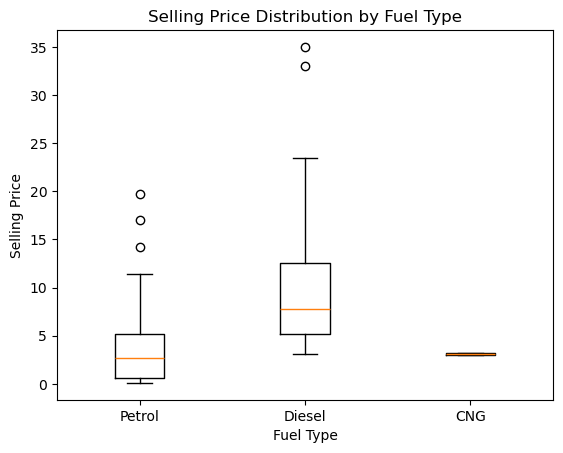

In [330]:
petrol_price=df.loc[df["Fuel_Type"]=="Petrol", "Selling_Price"]
diesel_price=df.loc[df["Fuel_Type"]=="Diesel", "Selling_Price"]
cng_price=df.loc[df["Fuel_Type"]=="CNG", "Selling_Price"]     
plt.boxplot([petrol_price, diesel_price, cng_price], labels=["Petrol", "Diesel", "CNG"])
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.title('Selling Price Distribution by Fuel Type')
plt.show()


C:\Users\bahug\AppData\Local\Temp\ipykernel_37144\4261574436.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dealer_price, Individual_price], labels=["Dealer", "Individual"])


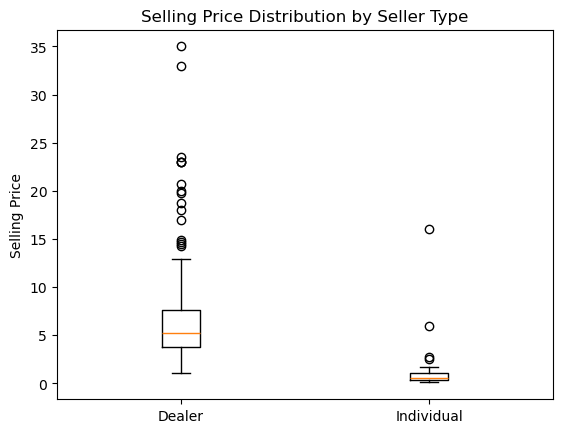

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

In [331]:
dealer_price = df.loc[df["Seller_Type"]=="Dealer","Selling_Price"]
Individual_price = df.loc[df["Seller_Type"]=="Individual","Selling_Price"]
plt.boxplot([dealer_price, Individual_price], labels=["Dealer", "Individual"])
plt.ylabel('Selling Price')
plt.title('Selling Price Distribution by Seller Type')
plt.show()
df["Transmission"].value_counts()

C:\Users\bahug\AppData\Local\Temp\ipykernel_37144\3302687486.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x, y], labels=["Manual", "Automatic"])


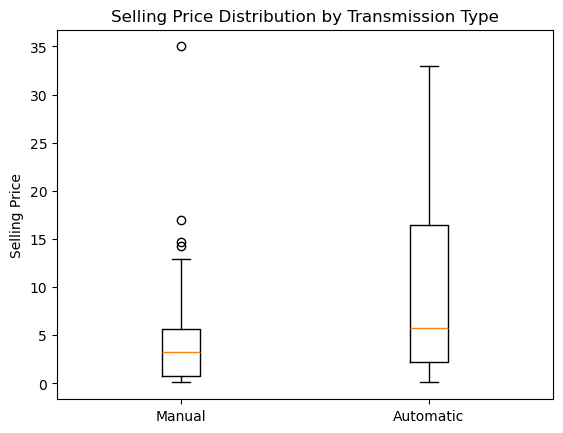

In [332]:
x=df.loc[df["Transmission"]=="Manual", "Selling_Price"]
y=df.loc[df["Transmission"]=="Automatic","Selling_Price"]
plt.boxplot([x, y], labels=["Manual", "Automatic"])
plt.ylabel('Selling Price')
plt.title('Selling Price Distribution by Transmission Type')    
plt.show()


C:\Users\bahug\AppData\Local\Temp\ipykernel_37144\205734403.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x, y, z], labels=["0", "1", "3"])


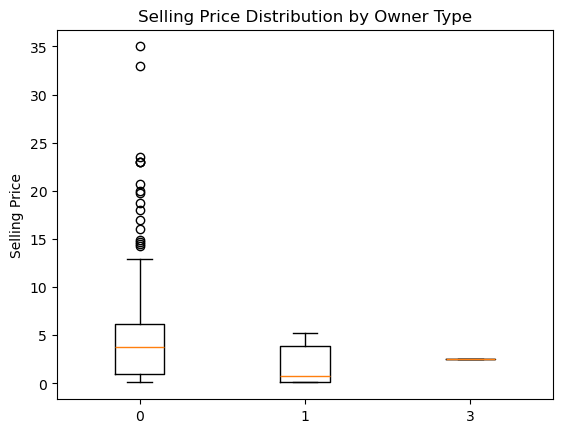

In [333]:
df["Owner"].value_counts()
x=df.loc[df["Owner"]==0, "Selling_Price"]
y=df.loc[df["Owner"]==1,"Selling_Price"]
z=df.loc[df["Owner"]==3,"Selling_Price"]
plt.boxplot([x, y, z], labels=["0", "1", "3"])
plt.ylabel('Selling Price')
plt.title('Selling Price Distribution by Owner Type')
plt.show()


In [334]:


print(pd.DataFrame({'Selling_Price': x, 'Present_Price': y}).corr())

               Selling_Price  Present_Price
Selling_Price            1.0            NaN
Present_Price            NaN            1.0


In [335]:
print(pd.DataFrame({"Selling Price":x,"Year":y}).corr())
print(df[["Selling_Price","Year"]].corr())
print(df[["Kms_Driven","Year"]].corr())

               Selling Price  Year
Selling Price            1.0   NaN
Year                     NaN   1.0
               Selling_Price      Year
Selling_Price       1.000000  0.236141
Year                0.236141  1.000000
            Kms_Driven      Year
Kms_Driven    1.000000 -0.524342
Year         -0.524342  1.000000


Axes(0.125,0.11;0.62x0.77)


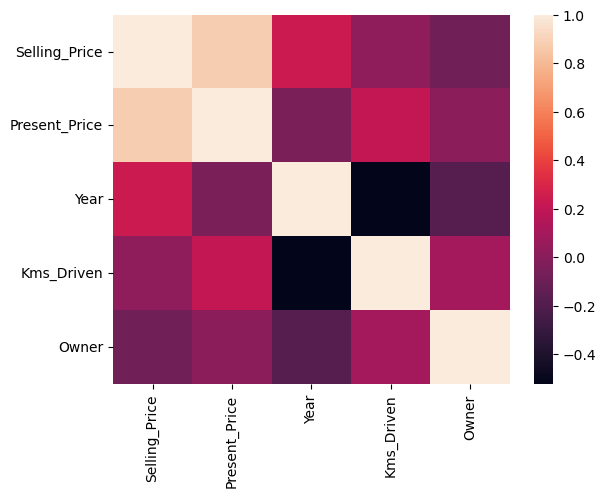

In [336]:
a=df[["Selling_Price","Present_Price","Year","Kms_Driven","Owner"]].corr()
print(sns.heatmap(a))


PRE-PROCESSING

In [337]:
x=df[["Year","Present_Price","Kms_Driven","Fuel_Type","Seller_Type","Transmission","Owner"]]
y=df["Selling_Price"]
print(x.head(5))
print(y.head(5))

   Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
0  2014           5.59       27000    Petrol      Dealer       Manual      0
1  2013           9.54       43000    Diesel      Dealer       Manual      0
2  2017           9.85        6900    Petrol      Dealer       Manual      0
3  2011           4.15        5200    Petrol      Dealer       Manual      0
4  2014           6.87       42450    Diesel      Dealer       Manual      0
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [338]:
j=pd.get_dummies(x[["Fuel_Type","Seller_Type","Transmission"]])
print(j.head(5))
print(j.shape)

   Fuel_Type_CNG  Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Dealer  \
0          False             False              True                True   
1          False              True             False                True   
2          False             False              True                True   
3          False             False              True                True   
4          False              True             False                True   

   Seller_Type_Individual  Transmission_Automatic  Transmission_Manual  
0                   False                   False                 True  
1                   False                   False                 True  
2                   False                   False                 True  
3                   False                   False                 True  
4                   False                   False                 True  
(301, 7)


In [339]:
z=pd.concat([x[["Year","Present_Price","Kms_Driven","Owner"]],j],axis=1)
print(z.head(5))
print(z.shape)  
print(z.dtypes)

   Year  Present_Price  Kms_Driven  Owner  Fuel_Type_CNG  Fuel_Type_Diesel  \
0  2014           5.59       27000      0          False             False   
1  2013           9.54       43000      0          False              True   
2  2017           9.85        6900      0          False             False   
3  2011           4.15        5200      0          False             False   
4  2014           6.87       42450      0          False              True   

   Fuel_Type_Petrol  Seller_Type_Dealer  Seller_Type_Individual  \
0              True                True                   False   
1             False                True                   False   
2              True                True                   False   
3              True                True                   False   
4             False                True                   False   

   Transmission_Automatic  Transmission_Manual  
0                   False                 True  
1                   False     

TRAIN-TEST SPLIT


In [340]:
x_train, x_test, y_train, y_test =train_test_split(z, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 11)
(61, 11)
(240,)
(61,)


In [341]:
scaler = StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)


TRAIN MODELS

In [342]:
lr=LinearRegression()
lr.fit(x_train_scaler, y_train)
#prediction
y_predict=lr.predict(x_test_scaler)



CLASSIFICATION


In [343]:
print("Mean Squared Error:")
print(mean_squared_error(y_test,y_predict))
print("R-squared Score:")
print(r2_score(y_test,y_predict))
print("Mean Absolute Error:")
print(mean_absolute_error(y_test,y_predict))

Mean Squared Error:
3.4788039706379013
R-squared Score:
0.8489813024899067
Mean Absolute Error:
1.2162256821297064


In [344]:
dt=DecisionTreeRegressor()
dt.fit(x_train_scaler, y_train)
y_predict=dt.predict(x_test_scaler)
print("Mean Squared Error:")
print(mean_squared_error(y_test,y_predict))
print("R-squared Score:")
print(r2_score(y_test,y_predict))
print("Mean Absolute Error:")
print(mean_absolute_error(y_test,y_predict))


Mean Squared Error:
1.49002131147541
R-squared Score:
0.9353165399313845
Mean Absolute Error:
0.7945901639344262


In [345]:
rf=RandomForestRegressor()
rf.fit(x_train_scaler, y_train)
y_predict=rf.predict(x_test_scaler)
print("Mean Squared Error:")
print(mean_squared_error(y_test,y_predict))
print("R-squared Score:")
print(r2_score(y_test,y_predict))
print("Mean Absolute Error:")
print(mean_absolute_error(y_test,y_predict))

Mean Squared Error:
0.8228139339344274
R-squared Score:
0.9642807442889207
Mean Absolute Error:
0.6145754098360664


In [346]:
print("Cross Validation Score for Linear Regression:")
print(cross_val_score(lr, x_train_scaler, y_train, cv=5))
print("Cross Validation Score for Decision Tree Regressor:")
print(cross_val_score(dt, x_train_scaler, y_train, cv=5))
print("Cross Validation Score for Random Forest Regressor:")
print(cross_val_score(rf, x_train_scaler, y_train, cv=5))

Cross Validation Score for Linear Regression:
[0.85420812 0.84855467 0.81145104 0.83374004 0.90176495]
Cross Validation Score for Decision Tree Regressor:
[0.96303551 0.93109705 0.7065963  0.89006715 0.93962095]
Cross Validation Score for Random Forest Regressor:
[0.95134289 0.82100484 0.80823378 0.87390042 0.94237648]


In [347]:
c=RandomForestRegressor( random_state=42)
t=GridSearchCV(c, param_grid={'n_estimators':[50,100,200],'max_depth':[5,10,15],'min_samples_split':[2,5,10]}, cv=5,scoring='r2')  
t.fit(x_train_scaler, y_train)
print(t.best_params_)
print(t.best_score_)


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
0.8875878913048343


In [348]:
print("Best Model Evaluation:")
best_model = t.best_estimator_
y_predict_e=best_model.predict(x_test_scaler)
print("Mean Squared Error:")
print(mean_squared_error(y_test,y_predict_e))
print("R-squared Score:")
print(r2_score(y_test,y_predict_e))
print("Mean Absolute Error:")
print(mean_absolute_error(y_test,y_predict_e))
print("Root Mean Squared Error:")
print(root_mean_squared_error(y_test,y_predict_e))


Best Model Evaluation:
Mean Squared Error:
0.88638003195242
R-squared Score:
0.9615212702255644
Mean Absolute Error:
0.609711905040602
Root Mean Squared Error:
0.9414775791023491


In [349]:
h=pd.DataFrame(best_model.feature_importances_, index=z.columns, columns=["Importance"]).sort_values(by="Importance", ascending=False)

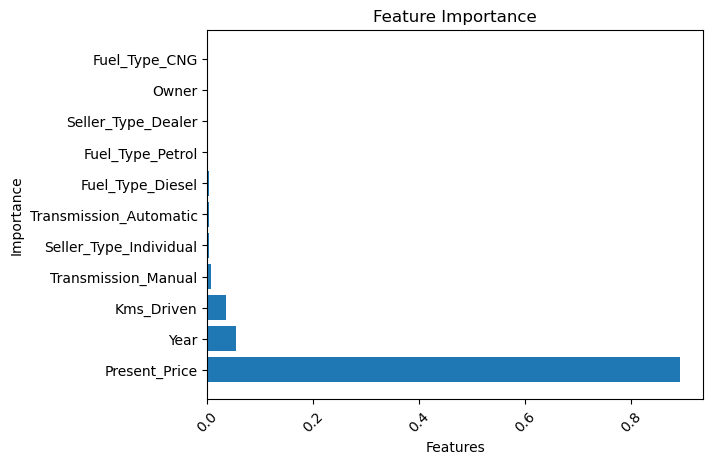

In [350]:
plt.barh(h.index, h["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()


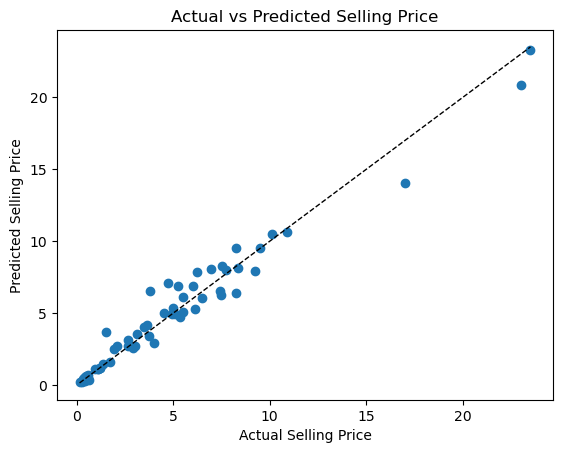

In [351]:
plt.scatter(y_test, y_predict_e)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")   
plt.title("Actual vs Predicted Selling Price")
plt.show()

residual analysis


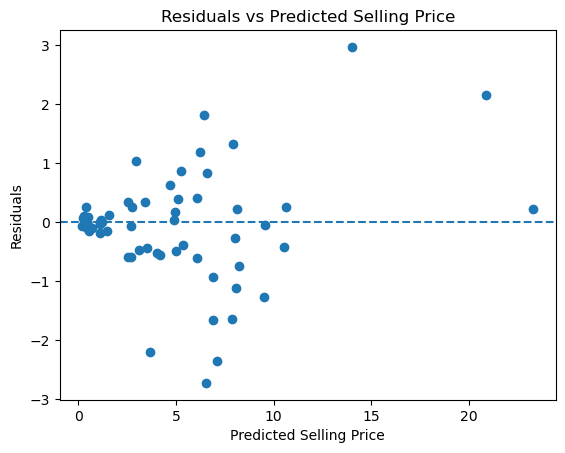

In [352]:
residual = y_test - y_predict_e
plt.scatter(y_predict_e, residual)
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Selling Price")
plt.axhline(y=0, linestyle='--')
plt.show()


In [353]:
import joblib
joblib.dump(best_model, 'car_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 
joblib.dump(z.columns.tolist(),'feature_names.pkl')

['feature_names.pkl']

In [354]:
load_m=joblib.load('car_price_model.pkl')
load_s=joblib.load('scaler.pkl')
predict=load_m.predict(load_s.transform(x_test))
print(predict[:10])
print(y_predict_e[:10])

[ 0.44507    10.53249167  4.91280303  0.21345667  8.0634      6.25638889
  1.12242085  0.60335377  0.46722     6.91924048]
[ 0.44507    10.53249167  4.91280303  0.21345667  8.0634      6.25638889
  1.12242085  0.60335377  0.46722     6.91924048]


In [355]:
print(x_test.shape)
print(x_test.columns)

(61, 11)
Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'Fuel_Type_CNG',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Dealer',
       'Seller_Type_Individual', 'Transmission_Automatic',
       'Transmission_Manual'],
      dtype='object')


In [359]:
input=pd.DataFrame({
    "Year":[2015],"Present_Price":[7.4],"Kms_Driven":[20000],"Fuel_Type":["Petrol"],"Seller_Type":["Dealer"],"Transmission":["Manual"],"Owner":[0]
    })
input_encoded=pd.get_dummies(input[["Fuel_Type","Seller_Type","Transmission"]])
print(input_encoded)
print(input_encoded.shape)

   Fuel_Type_Petrol  Seller_Type_Dealer  Transmission_Manual
0              True                True                 True
(1, 3)


In [357]:
r=pd.concat([input[["Year","Present_Price","Kms_Driven","Owner"]],input_encoded],axis=1)
print(r)
feature_names = joblib.load('feature_names.pkl')
input_final = r.reindex(columns=feature_names, fill_value=0)    
print(input_final)
input_scaled = load_s.transform(input_final)
input_prediction = load_m.predict(input_scaled)
print("Predicted Selling Price for the input data:", input_prediction[0])

   Year  Present_Price  Kms_Driven  Owner  Fuel_Type_Petrol  \
0  2015            7.4       20000      0              True   

   Seller_Type_Dealer  Transmission_Manual  
0                True                 True  
   Year  Present_Price  Kms_Driven  Owner  Fuel_Type_CNG  Fuel_Type_Diesel  \
0  2015            7.4       20000      0              0                 0   

   Fuel_Type_Petrol  Seller_Type_Dealer  Seller_Type_Individual  \
0              True                True                       0   

   Transmission_Automatic  Transmission_Manual  
0                       0                 True  
Predicted Selling Price for the input data: 5.422108333333333


In [358]:
print("input data shape:", input_final.shape)
print("predicted selling price:", input_prediction[0])

input data shape: (1, 11)
predicted selling price: 5.422108333333333
